In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
!pip3 install tslearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 8.0 MB/s eta 0:00:00


In [ ]:
import os
from os import listdir
import random
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler

## Load in Data

In [ ]:
# start from the data frame containing all the 400 step samples
all_samples = pd.read_csv('/content/gdrive/MyDrive/Next_Step/400_step_samples_forAll.csv')


In [ ]:
# remove all the unneccesary columns
all_samples = all_samples.drop(columns=['Unnamed: 0',' Latitude', ' SampleTimeFine' , ' Longitude',' Altitude', ' Vel_X', ' Vel_Y', ' Vel_Z'])

In [ ]:
# use surrounding data to fill in missing data
all_samples = all_samples.interpolate(method='linear', limit_direction='forward', axis=0)

In [ ]:
# making sure all sensors have equal classes
all_samples["sensor_place"].value_counts()

sensor_place
93    684000
8B    684000
9B    684000
B6    684000
95    684000
CC    684000
Name: count, dtype: int64

In [ ]:
# remove the calibration data points and the banked R/L to evaluate model performance
# without these variables because in our data collection they wont be included
all_samples = all_samples.drop(all_samples[all_samples["trial_label"] == 'calibration'].index)

In [ ]:
# making sure all surface types have equal classes
all_samples["trial_label"].value_counts()

trial_label
GR      432000
BNKR    432000
BNKL    432000
SLPD    432000
SLPU    432000
STD     432000
STU     432000
CS      432000
FE      432000
Name: count, dtype: int64

In [ ]:
# sort by person, trial, timestep order
all_samples = all_samples.sort_values(by=['participant_num', 'trial_num', 'og_df_order'])

In [ ]:
# seperating inputs by the sensor placement
all_samples_CC = all_samples.loc[all_samples['sensor_place'] == "CC"] # trunk
all_samples_95 = all_samples.loc[all_samples['sensor_place'] == "95"] # wrist
all_samples_93 = all_samples.loc[all_samples['sensor_place'] == "93"] # right thigh
all_samples_8B = all_samples.loc[all_samples['sensor_place'] == "8B"] # left thigh
all_samples_9B = all_samples.loc[all_samples['sensor_place'] == "9B"] # right shank
all_samples_B6 = all_samples.loc[all_samples['sensor_place'] == "B6"] # left shank

In [ ]:
# list of all of the separated dfs
sensor_dfs = [all_samples_CC, all_samples_95 , all_samples_93, all_samples_8B, all_samples_9B, all_samples_B6]

In [ ]:
all_sensor_metrics = []
all_sensor_non_metrics = []

# loop through each of the dfs by sensor placement
for df in sensor_dfs:
    sensor_df_metrics = []
    # establish which columns we retain
    metrics = pd.DataFrame(df, columns=[' Acc_X', ' Acc_Y',' Acc_Z', ' FreeAcc_X', ' FreeAcc_Y', ' FreeAcc_Z', ' Gyr_X', ' Gyr_Y',
                                                            ' Gyr_Z', ' Mag_X', ' Mag_Y', ' Mag_Z', ' VelInc_X', ' VelInc_Y',
                                                            ' VelInc_Z'])

    # normalize
    metrics = MinMaxScaler().fit_transform(metrics)
    # reshaping numpy array to the correct format (number of sequences, sequence length, number of features)
    numpy_metrics = metrics
    # reshape to have 1620 observations (54 * 30), of 400 timesteps, of 18 variables
    reshape_metrics = np.reshape(numpy_metrics, (1620, 400, 15))
    # add to list to consolidate
    sensor_df_metrics.append(reshape_metrics)
    all_sensor_metrics.append(sensor_df_metrics)

    # dataframe of the non measurements
    non_metrics = df[['participant_num', 'trial_num', 'trial_label']].copy()
    # reducing the trial label column down to just 1 label per sequence
    drop_doop = non_metrics.drop_duplicates()
    # one hot encode the surface labels (outcome labels)
    label_encoder = LabelEncoder()
    integer_encoded_labels = label_encoder.fit_transform(drop_doop['trial_label'])
    one_hot_encoded_labels = to_categorical(integer_encoded_labels)
    # make encoded variable into numpy
    numpy_result = np.array(one_hot_encoded_labels)
    # reshape to have 1620 observations of labels that are one hot encoded
    reshape_non_metrics = np.reshape(numpy_result, (1620, 9))
    all_sensor_non_metrics.append(reshape_non_metrics)


In [ ]:
# verification
len(all_sensor_metrics)

6

## Setting up X and Y train/test

In [ ]:
# establish X and Y variables
X_CC, X_95, X_93, X_8B, X_9B, X_B6 = np.array(all_sensor_metrics[0]), np.array(all_sensor_metrics[1]), np.array(all_sensor_metrics[2]), np.array(all_sensor_metrics[3]), np.array(all_sensor_metrics[4]), np.array(all_sensor_metrics[5])
Y_CC, Y_95, Y_93, Y_8B, Y_9B, Y_B6 = np.array(all_sensor_non_metrics[0]), np.array(all_sensor_non_metrics[1]), np.array(all_sensor_non_metrics[2]), np.array(all_sensor_non_metrics[3]), np.array(all_sensor_non_metrics[4]), np.array(all_sensor_non_metrics[5])

In [ ]:
Y_CC.shape

(1620, 9)

In [ ]:
# create variables that establish information that will be needed later SIGNAL VERSION
n_obs, n_timesteps, n_features, n_classes = 1377, 400, 15, 9

In [ ]:
# check variables
n_obs, n_timesteps, n_features, n_classes

(1377, 400, 18, 9)

## Train Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, Concatenate, Dense, Bidirectional

# clears the session for tensorflow
tf.keras.backend.clear_session()

# Define input shape
input_shape = (n_timesteps, n_features)
number_of_inputs = len(all_sensor_metrics)

# Define 6 parallel branches with different inputs
branch_models = []
inputs = []
branches = []
labels = []
count = 0

for _ in range(number_of_inputs):
    count += 1
    # input layer of the shape above
    input_layer = Input(shape=input_shape)
    inputs.append(input_layer)

    # CNN layer
    # batch norm first
    cnn_out = BatchNormalization()(input_layer)
    cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_out)
    cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
    cnn_out = Dropout(0.4)(cnn_out)

    # Bidirectional LSTM layer
    lstm_out = Bidirectional(LSTM(units=64, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)

    # Attention layer
    attention = Attention()([cnn_out, lstm_out])
    # Concatenate attention output with LSTM output
    merged = Concatenate(axis=-1)([lstm_out, attention])
    # Dense layer for individual branch output
    output_branch = Dense(units=n_classes, activation='softmax')(merged)

    # Print information about the branch before appending
    print(f"Branch {count} Summary:")
    branch_model = tf.keras.models.Model(inputs=input_layer, outputs=output_branch)
    branch_model.summary()
    print("\n" + "="*50 + "\n")
    # Add the branch model to the list
    branch_models.append(branch_model)
    # Add the branch to the list
    branches.append(output_branch)

# Concatenate the outputs of the 6 branches
merged_output = Concatenate(axis=-1)(branches)
# MLP layer
mlp_out = Flatten()(merged_output)
mlp_out = Dense(units=128, activation='relu')(mlp_out)
mlp_out = Dense(units=64, activation='relu')(mlp_out)
output_layer = Dense(units=n_classes, activation='softmax')(mlp_out)
# Create the model
model = tf.keras.models.Model(inputs=inputs, outputs=output_layer)

# Compile the model (if not compiled already)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
# Print the model summary
model.summary()


Branch 1 Summary:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 400, 18)]            0         []                            
                                                                                                  
 batch_normalization (Batch  (None, 400, 18)              72        ['input_1[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 conv1d (Conv1D)             (None, 398, 128)             7040      ['batch_normalization[0][0]'] 
                                                                                                  
 max_pooling1d (MaxPooling1  (None, 199, 128)             0         ['conv1d

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, Concatenate, Dense, Bidirectional, Flatten, BatchNormalization, MaxPooling1D, Dropout

# Assuming you have defined the variables n_obs, n_timesteps, n_features, and n_classes
num_samples = n_obs
sequence_length = n_timesteps
feature_dim = n_features
num_classes = n_classes

# Initialize KFold with desired number of folds
kfold = KFold(n_splits=10)

# Initialize lists to store evaluation metrics
accuracies = []
conf_matrices = []

# Split data into train-validation and test sets
X_CC_train_val, X_CC_test, Y_CC_train_val, Y_CC_test = train_test_split(X_CC, Y_CC, test_size=0.15, random_state=42, shuffle=True)
X_95_train_val, X_95_test, Y_95_train_val, Y_95_test = train_test_split(X_95, Y_95, test_size=0.15, random_state=42, shuffle=True)
X_93_train_val, X_93_test, Y_93_train_val, Y_93_test = train_test_split(X_93, Y_93, test_size=0.15, random_state=42, shuffle=True)
X_8B_train_val, X_8B_test, Y_8B_train_val, Y_8B_test = train_test_split(X_8B, Y_8B, test_size=0.15, random_state=42, shuffle=True)
X_9B_train_val, X_9B_test, Y_9B_train_val, Y_9B_test = train_test_split(X_9B, Y_9B, test_size=0.15, random_state=42, shuffle=True)
X_B6_train_val, X_B6_test, Y_B6_train_val, Y_B6_test = train_test_split(X_B6, Y_B6, test_size=0.15, random_state=42, shuffle=True)


# Define the model architecture
def create_model(input_shape):
    input_layers = []
    branches_outputs = []

    for i in range(6):
        input_layer = Input(shape=input_shape)
        input_layers.append(input_layer)

        # CNN layer
        cnn_out = BatchNormalization()(input_layer)
        cnn_out = Conv1D(filters=128, kernel_size=3, activation='relu')(cnn_out)
        cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
        cnn_out = Dropout(0.2)(cnn_out)

        # Bidirectional LSTM layer
        lstm_out = Bidirectional(LSTM(units=64, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)

        # Attention layer
        attention = Attention()([lstm_out, lstm_out])

        # Concatenate attention output with LSTM output
        merged = Concatenate(axis=-1)([lstm_out, attention])

        # Store output of each branch
        branches_outputs.append(merged)

    # Concatenate outputs of all branches
    merged_output = Concatenate(axis=-1)(branches_outputs)

    # MLP layer
    mlp_out = Flatten()(merged_output)
    mlp_out = Dense(units=128, activation='relu')(mlp_out)
    mlp_out = Dense(units=64, activation='relu')(mlp_out)
    output_layer = Dense(units=num_classes, activation='softmax')(mlp_out)

    # Create the model
    model = tf.keras.models.Model(inputs=input_layers, outputs=output_layer)
    return model

# Perform k-fold cross-validation
for train_index, val_index in kfold.split(X_CC_train_val):
    # Get the splits from each of the signal arrays
    X_CC_train, X_CC_valid = X_CC_train_val[train_index], X_CC_train_val[val_index]
    X_95_train, X_95_valid = X_95_train_val[train_index], X_95_train_val[val_index]
    X_93_train, X_93_valid = X_93_train_val[train_index], X_93_train_val[val_index]
    X_8B_train, X_8B_valid = X_8B_train_val[train_index], X_8B_train_val[val_index]
    X_9B_train, X_9B_valid = X_9B_train_val[train_index], X_9B_train_val[val_index]
    X_B6_train, X_B6_valid = X_B6_train_val[train_index], X_B6_train_val[val_index]

    # Define your Y data array based on the train and test indices
    Y_train, Y_valid = Y_93_train_val[train_index], Y_93_train_val[val_index]

    # clears the session for tensorflow
    tf.keras.backend.clear_session()

    model = create_model((sequence_length, feature_dim))

    # Compile the model (if not compiled already)
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # Train the model
    history = model.fit(x=[X_CC_train, X_95_train, X_93_train, X_8B_train, X_9B_train, X_B6_train],
                        y=Y_train,
                        epochs=200,
                        batch_size=128,
                        validation_data=([X_CC_valid, X_95_valid, X_93_valid, X_8B_valid, X_9B_valid, X_B6_valid], Y_valid),
                        callbacks=[callback])

    # Make predictions on the validation data
    fold_predictions = model.predict([X_CC_valid, X_95_valid, X_93_valid, X_8B_valid, X_9B_valid, X_B6_valid])

    # Convert predictions to class labels
    fold_predictions_labels = np.argmax(fold_predictions, axis=1)
    y_valid_labels = np.argmax(Y_valid, axis=1)

    # Compute accuracy for this fold
    accuracy = accuracy_score(y_valid_labels, fold_predictions_labels)
    # Store accuracy for this fold
    accuracies.append(accuracy)

    # Compute confusion matrix for this fold
    conf_matrix = confusion_matrix(y_valid_labels, fold_predictions_labels)
    conf_matrices.append(conf_matrix)

# Calculate average accuracy across all folds
avg_accuracy = sum(accuracies) / len(accuracies)
print("Average Accuracy:", avg_accuracy)

# Print confusion matrices for each fold
for i, conf_matrix in enumerate(conf_matrices):
    print("Confusion Matrix - Fold", i+1, ":\n", conf_matrix)

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate([X_CC_test, X_95_test, X_93_test, X_8B_test, X_9B_test, X_B6_test], Y_95_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Epoch 1/200
10/10 [==============================] - 91s 4s/step - loss: 2.0226 - accuracy: 0.3075 - val_loss: 2.1148 - val_accuracy: 0.1232
Epoch 2/200
10/10 [==============================] - 33s 3s/step - loss: 1.1589 - accuracy: 0.5981 - val_loss: 2.1246 - val_accuracy: 0.1594
Epoch 3/200
10/10 [==============================] - 33s 3s/step - loss: 0.8196 - accuracy: 0.7264 - val_loss: 2.2552 - val_accuracy: 0.1667
Epoch 4/200
10/10 [==============================] - 33s 3s/step - loss: 0.6023 - accuracy: 0.8216 - val_loss: 2.3788 - val_accuracy: 0.2464
Epoch 5/200
10/10 [==============================] - 32s 3s/step - loss: 0.4452 - accuracy: 0.8733 - val_loss: 2.4774 - val_accuracy: 0.2536
Epoch 6/200
10/10 [==============================] - 32s 3s/step - loss: 0.3630 - accuracy: 0.9056 - val_loss: 2.4993 - val_accuracy: 0.2391
Epoch 7/200
10/10 [==============================] - 31s 3s/step - loss: 0.2857 - accuracy: 0.9233 - val_loss: 2.5135 - val_accuracy: 0.2174
Epoch 8/200
1

KeyboardInterrupt: 

## Model performance graphs

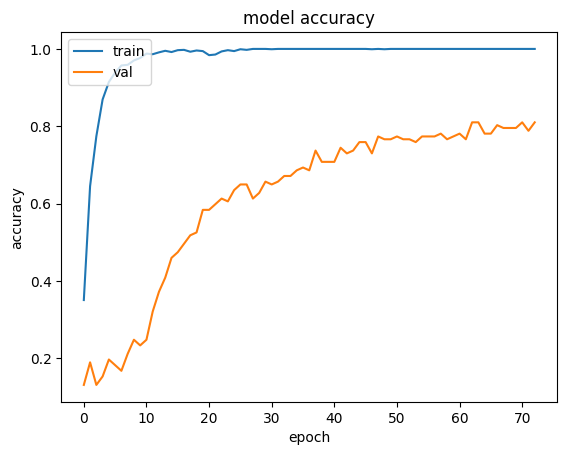

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

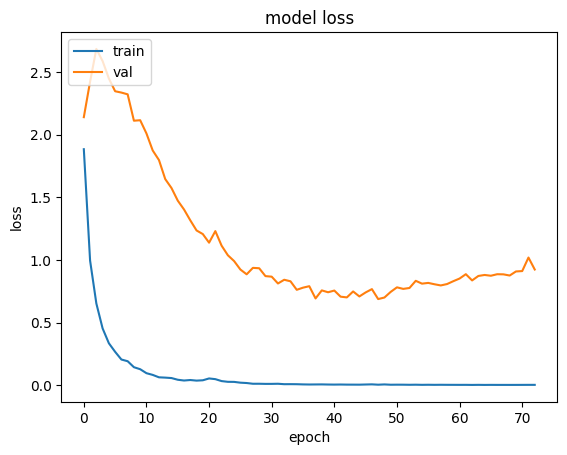

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# Get the weights of the individual branch models
branch_weights = []

for branch_model in branch_models:
    branch_weights.append(branch_model.get_weights())

In [ ]:
# Get the weights of the main model
main_model_weights = model.get_weights()


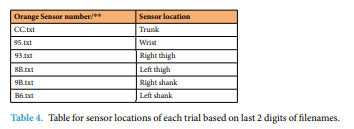

## Confusion Matrix

In [ ]:
x_tests = [X_CC_test, X_95_test, X_93_test, X_8B_test, X_9B_test, X_B6_test]

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score

# checking the evaluation scores on the test data

print("Evaluate on test data")
results = model.evaluate(x_tests, y_95_test, batch_size=128)
print("test loss, test acc:", results)

#Predict
y_prediction = model.predict(x_tests)

#Create confusion matrix and normalizes it over predicted (columns)
y_prediction = np.argmax(y_prediction, axis=1)
print(y_prediction)
Y_9B_test_proc = np.argmax(y_95_test, axis=1)
print(Y_9B_test_proc)
result = confusion_matrix(Y_9B_test_proc, y_prediction , normalize='pred')

# Compute F1 score
f1 = f1_score(Y_9B_test_proc, y_prediction, average='weighted')

print("F1 score:", f1)

Evaluate on test data
1/1 [==============================] - 0s 147ms/step - loss: 1.5936e-04 - accuracy: 1.0000
test loss, test acc: [0.00015936364070512354, 1.0]
1/1 [==============================] - 0s 148ms/step
[3 3]
[3 3]
F1 score: 1.0


In [ ]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

In [ ]:
# confusion matrix with labels
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['GR', 'BNKR', 'BNKL', 'SLPD', 'SLPU', 'STD', 'STU', 'CS', 'FE'])

cm_display.plot()
plt.show()

In [ ]:
# another confusion matrix
ConfusionMatrixDisplay.from_predictions(Y_9B_test_proc, y_prediction)